# AISO 벤치마크 — Rastrigin / Rosenbrock / TSP

| # | 벤치마크 | 난이도 포인트 | AISO가 증명하는 것 |
|---|---|---|---|
| 1 | **Rastrigin** (K=20) | 수만 개의 Local Minima | 조기 수렴 방지 / 다양성 유지 |
| 2 | **Rosenbrock** (K=20) | 좁고 평평한 바나나 계곡 | 후반 집중력 / Exploitation |
| 3 | **TSP** (30 도시) | 연속→이산 변환 (Random Key) | 범용 조합 최적화 적용 가능성 |

| 비교 알고리즘 | 선택 이유 |
|---|---|
| **PSO** | 가장 유명한 군집 알고리즘 |
| **Firefly Algorithm** | 에이전트간 인력 세기가 다름 — AISO와 구조적으로 가장 유사 |
| **Differential Evolution** | pairwise difference 사용 — AISO와 유사 |
| **Random Search** | 하한선 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

N_AGENTS = 30
N_ITER   = 200
ALPHA    = 0.3
BETA     = 0.1
N_RUNS   = 5
SEEDS    = [42, 123, 777, 2024, 31415]

PSO_W, PSO_C1, PSO_C2 = 0.729, 1.494, 1.494
FA_BETA0, FA_GAMMA, FA_ALPHA = 1.0, 1.0, 0.2
DE_F, DE_CR = 0.8, 0.9

ALG_COLORS = {
    'AISO':    '#DD8452',
    'PSO':     '#4C72B0',
    'Firefly': '#C44E52',
    'DE':      '#55A868',
    'Random':  '#8C8C8C',
}
print('설정 완료')

설정 완료


In [2]:
def run_aiso(f, K, seed=42):
    np.random.seed(seed)
    M  = np.random.uniform(0, 2, (K, K)).astype(np.float32)
    aX = np.random.rand(N_AGENTS, K).astype(np.float32)
    aW = np.random.dirichlet(np.ones(K), N_AGENTS).astype(np.float32)
    aS = np.array([f(aX[i]) for i in range(N_AGENTS)])
    bX = aX[np.argmax(aS)].copy(); bS = float(aS.max())
    curve = [bS]
    for _ in range(N_ITER):
        for i in range(N_AGENTS):
            j  = np.random.choice([k for k in range(N_AGENTS) if k != i])
            c  = float(aW[i] @ M @ aW[j])
            nX = np.clip(aX[i] + ALPHA * c * (aX[j] - aX[i]), 0, 1)
            ns = f(nX)
            if ns > aS[i]:
                aX[i] = nX; aS[i] = ns
                aW[i] = (1 - BETA) * aW[i] + BETA * aW[j]
                aW[i] /= aW[i].sum()
        if aS.max() > bS: bS = float(aS.max()); bX = aX[np.argmax(aS)].copy()
        curve.append(bS)
    return bX, bS, curve


def run_pso(f, K, seed=42):
    np.random.seed(seed)
    X  = np.random.rand(N_AGENTS, K).astype(np.float32)
    V  = np.zeros_like(X)
    S  = np.array([f(X[i]) for i in range(N_AGENTS)])
    pX = X.copy(); pS = S.copy()
    bX = X[np.argmax(S)].copy(); bS = float(S.max())
    curve = [bS]
    for _ in range(N_ITER):
        r1 = np.random.rand(N_AGENTS, K).astype(np.float32)
        r2 = np.random.rand(N_AGENTS, K).astype(np.float32)
        V  = PSO_W*V + PSO_C1*r1*(pX-X) + PSO_C2*r2*(bX-X)
        X  = np.clip(X + V, 0, 1)
        S  = np.array([f(X[i]) for i in range(N_AGENTS)])
        upd = S > pS; pX[upd]=X[upd]; pS[upd]=S[upd]
        if pS.max() > bS: bS=float(pS.max()); bX=pX[np.argmax(pS)].copy()
        curve.append(bS)
    return bX, bS, curve


def run_firefly(f, K, seed=42):
    np.random.seed(seed)
    X = np.random.rand(N_AGENTS, K).astype(np.float32)
    S = np.array([f(X[i]) for i in range(N_AGENTS)])
    bX = X[np.argmax(S)].copy(); bS = float(S.max())
    curve = [bS]
    for _ in range(N_ITER):
        for i in range(N_AGENTS):
            for j in range(N_AGENTS):
                if S[j] <= S[i]: continue
                r2   = float(np.sum((X[i] - X[j])**2))
                beta = FA_BETA0 * np.exp(-FA_GAMMA * r2)
                nX   = np.clip(X[i] + beta*(X[j]-X[i]) + FA_ALPHA*(np.random.rand(K).astype(np.float32)-0.5), 0, 1)
                ns   = f(nX)
                if ns > S[i]: X[i]=nX; S[i]=ns
        if S.max() > bS: bS=float(S.max()); bX=X[np.argmax(S)].copy()
        curve.append(bS)
    return bX, bS, curve


def run_de(f, K, seed=42):
    np.random.seed(seed)
    X = np.random.rand(N_AGENTS, K).astype(np.float32)
    S = np.array([f(X[i]) for i in range(N_AGENTS)])
    bX = X[np.argmax(S)].copy(); bS = float(S.max())
    curve = [bS]
    idx_all = np.arange(N_AGENTS)
    for _ in range(N_ITER):
        for i in range(N_AGENTS):
            cands = idx_all[idx_all != i]
            a, b, c = cands[np.random.choice(len(cands), 3, replace=False)]
            mutant  = np.clip(X[a] + DE_F*(X[b]-X[c]), 0, 1)
            cross   = np.random.rand(K) < DE_CR
            if not cross.any(): cross[np.random.randint(K)] = True
            trial = np.where(cross, mutant, X[i]).astype(np.float32)
            ns    = f(trial)
            if ns > S[i]: X[i]=trial; S[i]=ns
        if S.max() > bS: bS=float(S.max()); bX=X[np.argmax(S)].copy()
        curve.append(bS)
    return bX, bS, curve


def run_random(f, K, seed=42):
    np.random.seed(seed)
    bS = float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(N_AGENTS)))
    curve = [bS]
    for _ in range(N_ITER):
        bS = max(bS, float(max(f(np.random.rand(K).astype(np.float32)) for _ in range(N_AGENTS))))
        curve.append(bS)
    return None, bS, curve


RUNNERS = [('AISO', run_aiso), ('PSO', run_pso), ('Firefly', run_firefly), ('DE', run_de), ('Random', run_random)]
print(f'알고리즘 {len(RUNNERS)}개 준비: {[r[0] for r in RUNNERS]}')

알고리즘 5개 준비: ['AISO', 'PSO', 'Firefly', 'DE', 'Random']


In [3]:
def run_all(f, K):
    results, curves = {}, {}
    for name, runner in RUNNERS:
        r_list, c_list = [], []
        for seed in SEEDS[:N_RUNS]:
            _, s, c = runner(f, K, seed=seed)
            r_list.append(s); c_list.append(c)
        results[name] = r_list; curves[name] = c_list
        print(f'  {name:<10} 완료  mean={np.mean(r_list):.4f}')
    return results, curves


def plot_convergence(curves, title, ax, optimal=None):
    for name, cv in curves.items():
        arr  = np.array(cv)
        mean = arr.mean(0); std = arr.std(0)
        x    = np.arange(len(mean))
        lw   = 2.5 if name == 'AISO' else 1.5
        ax.plot(x, mean, color=ALG_COLORS[name], lw=lw, label=name)
        ax.fill_between(x, mean-std, mean+std, alpha=0.12, color=ALG_COLORS[name])
    if optimal is not None:
        ax.axhline(optimal, color='green', ls=':', lw=1.2, label=f'Optimal={optimal}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Iteration'); ax.set_ylabel('Best Score (↑)')
    ax.legend(frameon=False, fontsize=8)


def print_table(results, name, K):
    print(f'\n{"="*65}')
    print(f'  {name} (K={K}, {N_RUNS} runs)')
    print(f'  {"알고리즘":<12} {"평균":>10}  {"표준편차":>10}  {"최선":>10}')
    print(f'  {"-"*58}')
    best = max(np.mean(v) for v in results.values())
    for n, vals in results.items():
        m = np.mean(vals)
        print(f'  {n:<12} {m:>10.4f}  {np.std(vals):>10.4f}  {np.max(vals):>10.4f}{" ★" if m==best else ""}')
    print(f'{"="*65}')

print('헬퍼 완료')

헬퍼 완료


---
## 1. Rastrigin — 함정 회피 테스트

$$f(\mathbf{x}) = An + \sum_{i=1}^{n}\left[x_i^2 - A\cos(2\pi x_i)\right], \quad x_i \in [-5.12, 5.12]$$

전역 최솟값 = **0** at $\mathbf{x}=\mathbf{0}$. PSO·Firefly·DE 모두 함정에 걸리면 탈출 못함.

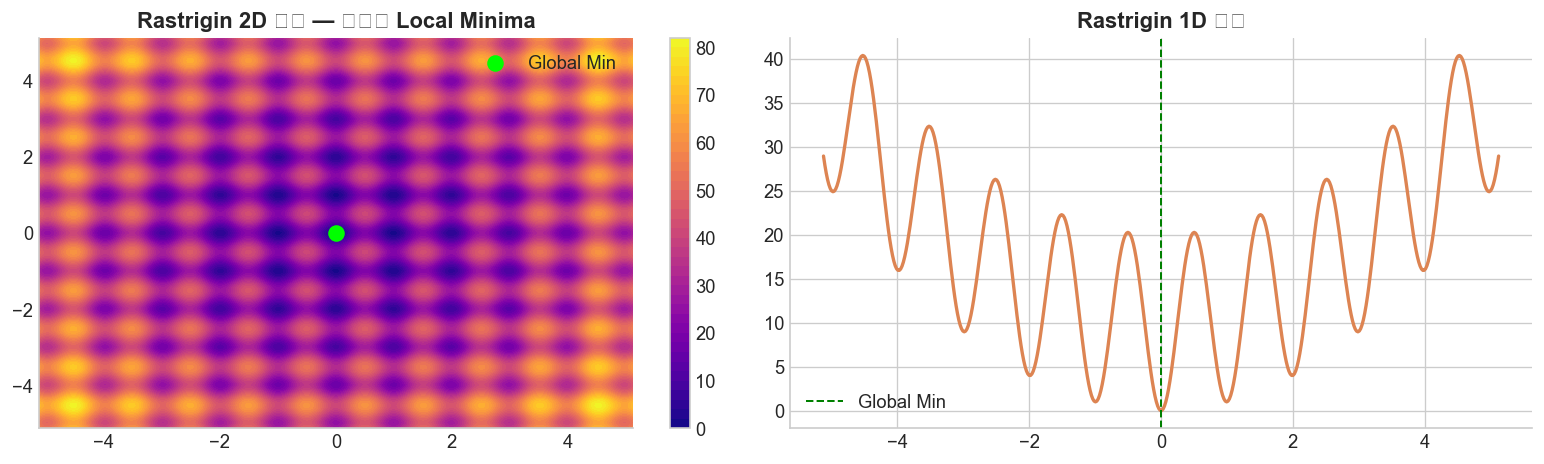

In [4]:
grid = np.linspace(-5.12, 5.12, 400)
xx, yy = np.meshgrid(grid, grid)
zz = 20 + xx**2 + yy**2 - 10*(np.cos(2*np.pi*xx) + np.cos(2*np.pi*yy))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].contourf(xx, yy, zz, levels=50, cmap='plasma')
axes[0].scatter([0], [0], color='lime', s=80, zorder=5, label='Global Min')
axes[0].set_title('Rastrigin 2D 지형 — 계란판 Local Minima', fontweight='bold')
axes[0].legend(frameon=False); plt.colorbar(im, ax=axes[0])

x1d = np.linspace(-5.12, 5.12, 500)
axes[1].plot(x1d, 10 + x1d**2 - 10*np.cos(2*np.pi*x1d), color='#DD8452', lw=2)
axes[1].axvline(0, color='green', ls='--', lw=1.2, label='Global Min')
axes[1].set_title('Rastrigin 1D 단면', fontweight='bold')
axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig('benchmark_rastrigin_landscape.png', bbox_inches='tight'); plt.show()

Rastrigin K=20 실험...
  AISO       완료  mean=-92.8706
  PSO        완료  mean=-43.5276
  Firefly    완료  mean=-87.1957
  DE         완료  mean=-174.4634
  Random     완료  mean=-210.7676

  Rastrigin (K=20, 5 runs)
  알고리즘                 평균        표준편차          최선
  ----------------------------------------------------------
  AISO           -92.8706      9.3300    -78.2879
  PSO            -43.5276     18.1538    -22.3416 ★
  Firefly        -87.1957      9.2176    -71.6092
  DE            -174.4634     12.7957   -152.7986
  Random        -210.7676      7.9381   -197.3229


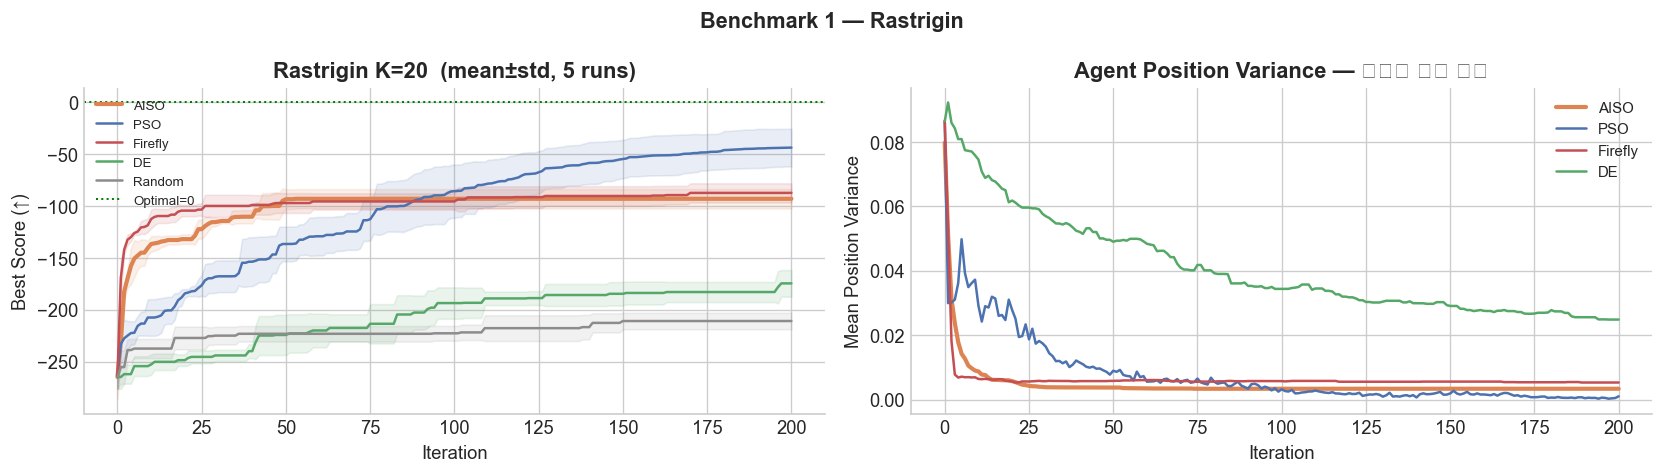

In [5]:
def make_rastrigin(K, A=10):
    lo, hi = -5.12, 5.12
    def f(X):
        x = X * (hi - lo) + lo
        return -(A * K + np.sum(x**2 - A * np.cos(2 * np.pi * x)))
    return f

K_RAS = 20; f_ras = make_rastrigin(K_RAS)
print(f'Rastrigin K={K_RAS} 실험...')
res_ras, curves_ras = run_all(f_ras, K_RAS)
print_table(res_ras, 'Rastrigin', K_RAS)

# 에이전트 분산 추적 — 4개 알고리즘
def get_variance_hist(runner_name, runner_fn, f, K, seed=42):
    np.random.seed(seed)
    if runner_name == 'AISO':
        M=np.random.uniform(0,2,(K,K)).astype(np.float32)
        X=np.random.rand(N_AGENTS,K).astype(np.float32)
        W=np.random.dirichlet(np.ones(K),N_AGENTS).astype(np.float32)
        S=np.array([f(X[i]) for i in range(N_AGENTS)]); bS=float(S.max())
        h=[float(np.var(X,0).mean())]
        for _ in range(N_ITER):
            for i in range(N_AGENTS):
                j=np.random.choice([k for k in range(N_AGENTS) if k!=i])
                c=float(W[i]@M@W[j])
                nX=np.clip(X[i]+ALPHA*c*(X[j]-X[i]),0,1); ns=f(nX)
                if ns>S[i]: X[i]=nX;S[i]=ns;W[i]=(1-BETA)*W[i]+BETA*W[j];W[i]/=W[i].sum()
            if S.max()>bS: bS=float(S.max())
            h.append(float(np.var(X,0).mean()))
    elif runner_name == 'PSO':
        X=np.random.rand(N_AGENTS,K).astype(np.float32); V=np.zeros_like(X)
        S=np.array([f(X[i]) for i in range(N_AGENTS)])
        pX=X.copy();pS=S.copy();bX=X[np.argmax(S)].copy();bS=float(S.max())
        h=[float(np.var(X,0).mean())]
        for _ in range(N_ITER):
            r1=np.random.rand(N_AGENTS,K).astype(np.float32)
            r2=np.random.rand(N_AGENTS,K).astype(np.float32)
            V=PSO_W*V+PSO_C1*r1*(pX-X)+PSO_C2*r2*(bX-X); X=np.clip(X+V,0,1)
            S=np.array([f(X[i]) for i in range(N_AGENTS)])
            upd=S>pS;pX[upd]=X[upd];pS[upd]=S[upd]
            if pS.max()>bS: bS=float(pS.max());bX=pX[np.argmax(pS)].copy()
            h.append(float(np.var(X,0).mean()))
    elif runner_name == 'Firefly':
        X=np.random.rand(N_AGENTS,K).astype(np.float32)
        S=np.array([f(X[i]) for i in range(N_AGENTS)]); bS=float(S.max())
        h=[float(np.var(X,0).mean())]
        for _ in range(N_ITER):
            for i in range(N_AGENTS):
                for j in range(N_AGENTS):
                    if S[j]<=S[i]: continue
                    beta=FA_BETA0*np.exp(-FA_GAMMA*float(np.sum((X[i]-X[j])**2)))
                    nX=np.clip(X[i]+beta*(X[j]-X[i])+FA_ALPHA*(np.random.rand(K).astype(np.float32)-0.5),0,1)
                    ns=f(nX)
                    if ns>S[i]: X[i]=nX;S[i]=ns
            if S.max()>bS: bS=float(S.max())
            h.append(float(np.var(X,0).mean()))
    else:  # DE
        X=np.random.rand(N_AGENTS,K).astype(np.float32)
        S=np.array([f(X[i]) for i in range(N_AGENTS)]); bS=float(S.max())
        h=[float(np.var(X,0).mean())]; idx_all=np.arange(N_AGENTS)
        for _ in range(N_ITER):
            for i in range(N_AGENTS):
                cands=idx_all[idx_all!=i]; a,b,c=cands[np.random.choice(len(cands),3,replace=False)]
                mutant=np.clip(X[a]+DE_F*(X[b]-X[c]),0,1)
                cross=np.random.rand(K)<DE_CR
                if not cross.any(): cross[np.random.randint(K)]=True
                trial=np.where(cross,mutant,X[i]).astype(np.float32); ns=f(trial)
                if ns>S[i]: X[i]=trial;S[i]=ns
            if S.max()>bS: bS=float(S.max())
            h.append(float(np.var(X,0).mean()))
    return h

var_hists = {n: get_variance_hist(n, fn, f_ras, K_RAS) for n, fn in RUNNERS if n != 'Random'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_convergence(curves_ras, f'Rastrigin K={K_RAS}  (mean±std, {N_RUNS} runs)', axes[0], optimal=0)
for name, h in var_hists.items():
    axes[1].plot(h, color=ALG_COLORS[name], lw=2.5 if name=='AISO' else 1.5, label=name)
axes[1].set_title('Agent Position Variance — 다양성 유지 비교', fontweight='bold')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Mean Position Variance')
axes[1].legend(frameon=False, fontsize=9)
plt.suptitle('Benchmark 1 — Rastrigin', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('benchmark_rastrigin_result.png', bbox_inches='tight'); plt.show()

---
## 2. Rosenbrock — 수렴성 및 미세조정 테스트

$$f(\mathbf{x}) = \sum_{i=1}^{n-1}\left[100(x_{i+1}-x_i^2)^2 + (1-x_i)^2\right], \quad x_i \in [-2, 2]$$

전역 최솟값 = **0** at $\mathbf{x}=(1,\dots,1)$. Firefly는 후반 수렴력 약화, DE는 좁은 계곡에서 돌연변이가 튐.

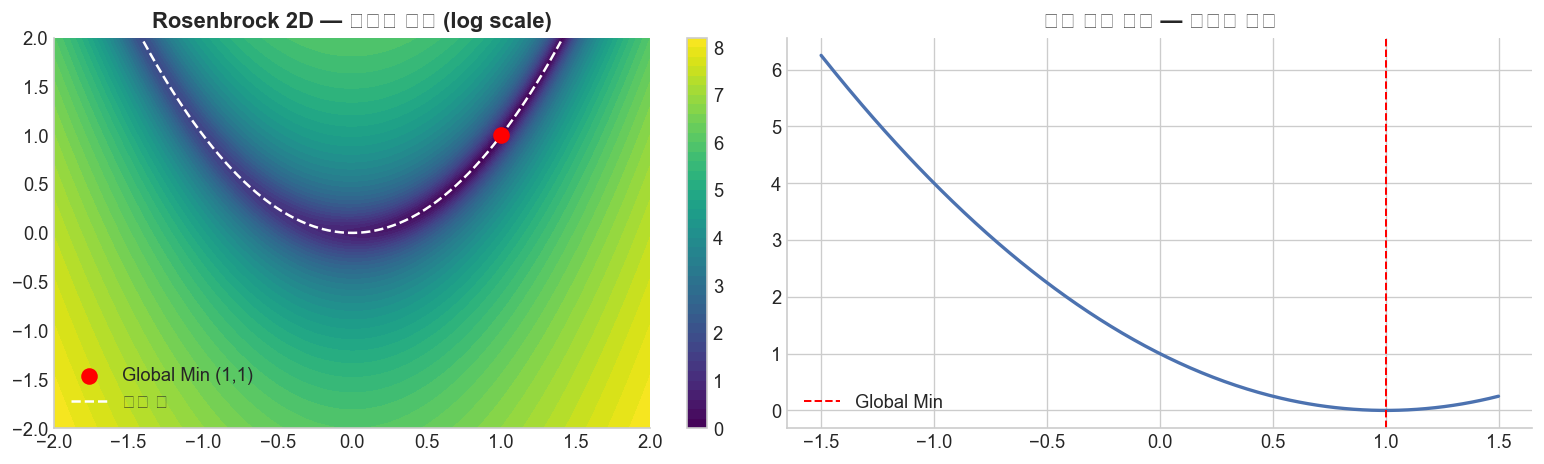

In [6]:
grid = np.linspace(-2, 2, 400)
xx, yy = np.meshgrid(grid, grid)
zz = 100*(yy - xx**2)**2 + (1 - xx)**2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].contourf(xx, yy, np.log1p(zz), levels=50, cmap='viridis')
axes[0].scatter([1], [1], color='red', s=80, zorder=5, label='Global Min (1,1)')
t = np.linspace(-1.4, 1.4, 200)
axes[0].plot(t, t**2, 'w--', lw=1.5, label='계곡 축')
axes[0].set_title('Rosenbrock 2D — 바나나 계곡 (log scale)', fontweight='bold')
axes[0].legend(frameon=False); plt.colorbar(im, ax=axes[0])

xv = np.linspace(-1.5, 1.5, 300)
axes[1].plot(xv, (1-xv)**2, color='#4C72B0', lw=2)
axes[1].axvline(1, color='red', ls='--', lw=1.2, label='Global Min')
axes[1].set_title('계곡 내부 단면 — 완만한 경사', fontweight='bold')
axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig('benchmark_rosenbrock_landscape.png', bbox_inches='tight'); plt.show()

Rosenbrock K=20 실험...
  AISO       완료  mean=-122.8502
  PSO        완료  mean=-41.4514
  Firefly    완료  mean=-46.2105
  DE         완료  mean=-221.0090
  Random     완료  mean=-1506.3445

  Rosenbrock (K=20, 5 runs)
  알고리즘                 평균        표준편차          최선
  ----------------------------------------------------------
  AISO          -122.8502     41.3751    -63.8317
  PSO            -41.4514     29.4203    -16.6573 ★
  Firefly        -46.2105      5.6111    -35.7682
  DE            -221.0090     92.0009   -160.4797
  Random       -1506.3445    103.8898  -1359.9678


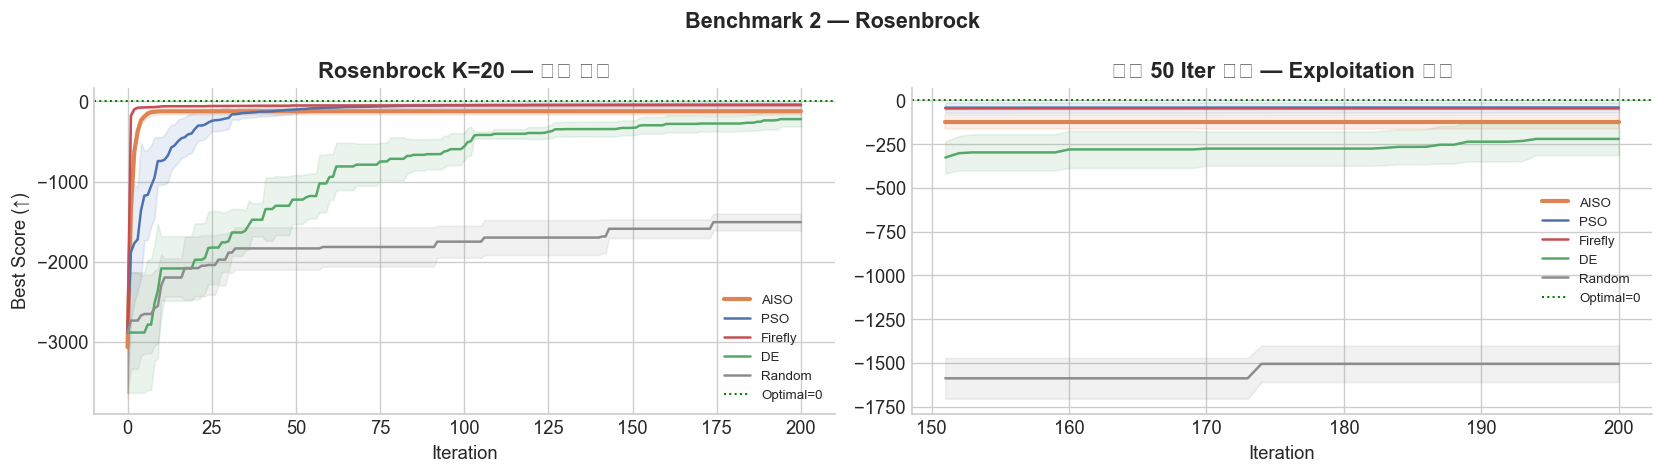

In [7]:
def make_rosenbrock(K):
    lo, hi = -2.0, 2.0
    def f(X):
        x = X * (hi - lo) + lo
        return -np.sum(100*(x[1:]-x[:-1]**2)**2 + (1-x[:-1])**2)
    return f

K_ROS = 20; f_ros = make_rosenbrock(K_ROS)
print(f'Rosenbrock K={K_ROS} 실험...')
res_ros, curves_ros = run_all(f_ros, K_ROS)
print_table(res_ros, 'Rosenbrock', K_ROS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_convergence(curves_ros, f'Rosenbrock K={K_ROS} — 전체 수렴', axes[0], optimal=0)

for name, cv in curves_ros.items():
    arr = np.array(cv)[:, -50:]
    mean = arr.mean(0); std = arr.std(0)
    x = np.arange(N_ITER-49, N_ITER+1)
    axes[1].plot(x, mean, color=ALG_COLORS[name], lw=2.5 if name=='AISO' else 1.5, label=name)
    axes[1].fill_between(x, mean-std, mean+std, alpha=0.12, color=ALG_COLORS[name])
axes[1].axhline(0, color='green', ls=':', lw=1.2, label='Optimal=0')
axes[1].set_title('후반 50 Iter 확대 — Exploitation 비교', fontweight='bold')
axes[1].set_xlabel('Iteration'); axes[1].legend(frameon=False, fontsize=8)

plt.suptitle('Benchmark 2 — Rosenbrock', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('benchmark_rosenbrock_result.png', bbox_inches='tight'); plt.show()

---
## 3. TSP — 범용 조합 최적화 테스트

**Random Key 인코딩**: $X \in [0,1]^n$ → $\text{argsort}(X)$ = 방문 순서. 모든 알고리즘 동일 인코딩 사용.

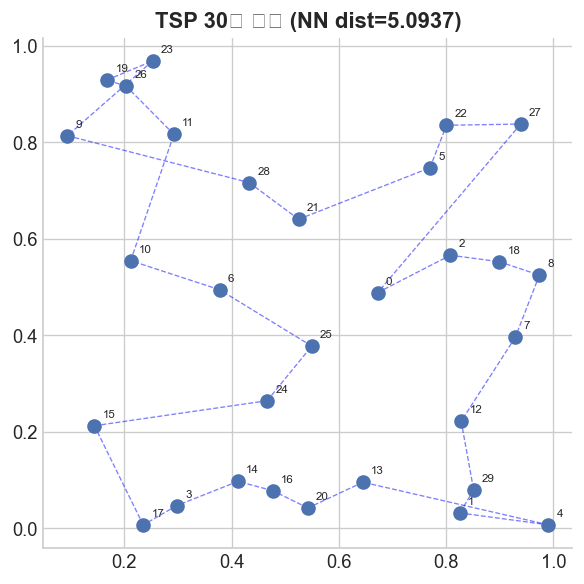

Nearest Neighbor 기준선: 5.0937


In [8]:
N_CITIES = 30
np.random.seed(99)
CITIES = np.random.rand(N_CITIES, 2).astype(np.float32)
DIST   = np.sqrt(((CITIES[:,None]-CITIES[None,:])**2).sum(2))

def tsp_f(X):
    tour = np.argsort(X)
    return -sum(DIST[tour[i], tour[(i+1)%N_CITIES]] for i in range(N_CITIES))

def nearest_neighbor(start=0):
    visited=[start]; remaining=list(range(N_CITIES)); remaining.remove(start)
    while remaining:
        last=visited[-1]; nearest=min(remaining, key=lambda c: DIST[last,c])
        visited.append(nearest); remaining.remove(nearest)
    return visited, sum(DIST[visited[i],visited[(i+1)%N_CITIES]] for i in range(N_CITIES))

nn_tour, nn_dist = nearest_neighbor(); nn_score = -nn_dist

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(CITIES[:,0], CITIES[:,1], s=60, color='#4C72B0', zorder=3)
for i,(x,y) in enumerate(CITIES): ax.annotate(str(i),(x,y),textcoords='offset points',xytext=(5,5),fontsize=7)
for i in range(N_CITIES):
    a,b=nn_tour[i],nn_tour[(i+1)%N_CITIES]
    ax.plot([CITIES[a,0],CITIES[b,0]],[CITIES[a,1],CITIES[b,1]],'b--',lw=0.8,alpha=0.5)
ax.set_title(f'TSP {N_CITIES}개 도시 (NN dist={nn_dist:.4f})', fontweight='bold')
plt.tight_layout(); plt.savefig('benchmark_tsp_cities.png', bbox_inches='tight'); plt.show()
print(f'Nearest Neighbor 기준선: {nn_dist:.4f}')

TSP 30개 도시 실험...
  AISO       완료  mean=-11.8432
  PSO        완료  mean=-8.0984
  Firefly    완료  mean=-10.0828
  DE         완료  mean=-9.1890
  Random     완료  mean=-11.9564

  TSP (30 cities) (K=30, 5 runs)
  알고리즘                 평균        표준편차          최선
  ----------------------------------------------------------
  AISO           -11.8432      0.4686    -10.9732
  PSO             -8.0984      0.3705     -7.7511 ★
  Firefly        -10.0828      0.3726     -9.3547
  DE              -9.1890      0.5292     -8.5283
  Random         -11.9564      0.2444    -11.6298
  Nearest Neighbor     -5.0937


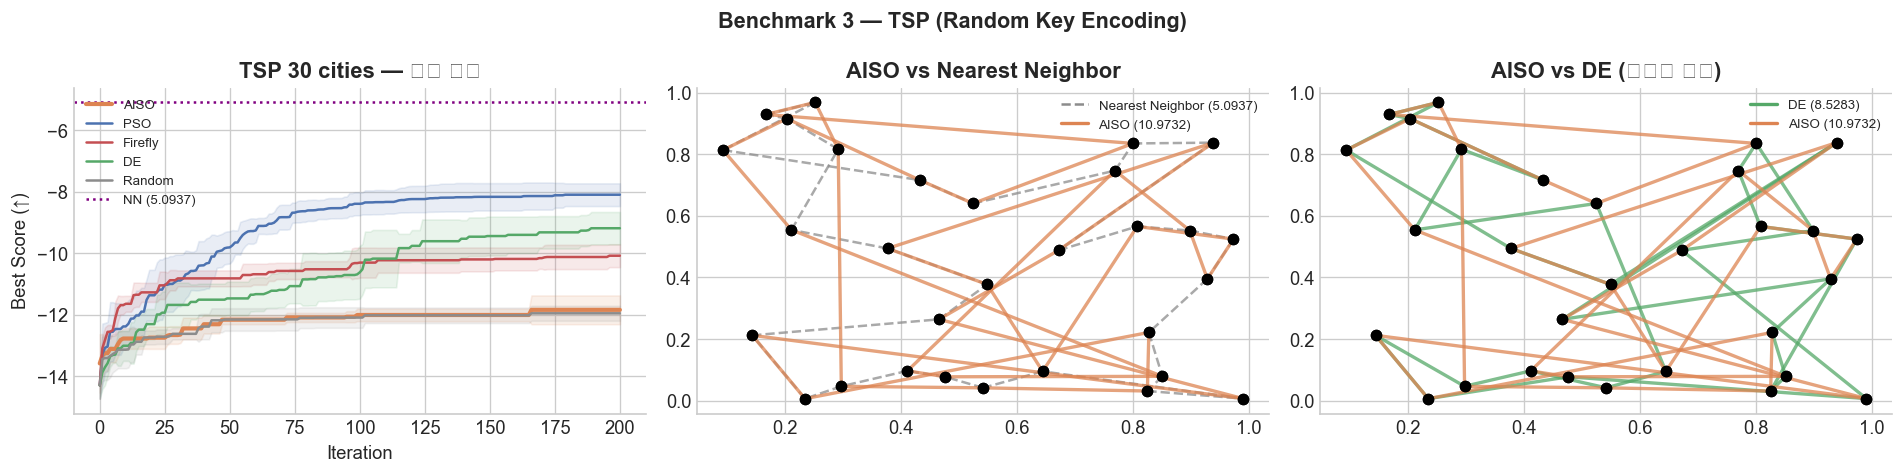

AISO vs NN: 5.0937 → 10.9732  (-115.4%)
AISO vs DE: 8.5283 → 10.9732  (-28.7%)


In [9]:
K_TSP = N_CITIES
print(f'TSP {N_CITIES}개 도시 실험...')
res_tsp, curves_tsp = run_all(tsp_f, K_TSP)
print_table(res_tsp, f'TSP ({N_CITIES} cities)', K_TSP)
print(f'  {"Nearest Neighbor":<12}  {nn_score:>10.4f}')

best_X_aiso, _, _ = run_aiso(tsp_f, K_TSP, seed=SEEDS[np.argmax(res_tsp['AISO'])])
best_X_de,   _, _ = run_de(tsp_f, K_TSP,   seed=SEEDS[np.argmax(res_tsp['DE'])])
tour_aiso = np.argsort(best_X_aiso); dist_aiso = -tsp_f(best_X_aiso)
tour_de   = np.argsort(best_X_de);   dist_de   = -tsp_f(best_X_de)

def draw_tour(ax, tour, color, label, lw=1.5, ls='-'):
    for i in range(N_CITIES):
        a,b=tour[i],tour[(i+1)%N_CITIES]
        ax.plot([CITIES[a,0],CITIES[b,0]],[CITIES[a,1],CITIES[b,1]],color=color,lw=lw,ls=ls,alpha=0.75)
    ax.scatter(CITIES[:,0],CITIES[:,1],s=35,color='k',zorder=3)
    ax.plot([],[],color=color,lw=lw,ls=ls,label=label)

fig = plt.figure(figsize=(16,4)); gs = gridspec.GridSpec(1,3,figure=fig)

ax0 = fig.add_subplot(gs[0])
plot_convergence(curves_tsp, f'TSP {N_CITIES} cities — 수렴 곡선', ax0)
ax0.axhline(nn_score, color='purple', ls=':', lw=1.5, label=f'NN ({nn_dist:.4f})')
ax0.legend(frameon=False, fontsize=8)

ax1 = fig.add_subplot(gs[1])
draw_tour(ax1, nn_tour,   '#8C8C8C', f'Nearest Neighbor ({nn_dist:.4f})', ls='--')
draw_tour(ax1, tour_aiso, '#DD8452', f'AISO ({dist_aiso:.4f})', lw=2)
ax1.set_title('AISO vs Nearest Neighbor', fontweight='bold'); ax1.legend(frameon=False, fontsize=8)

ax2 = fig.add_subplot(gs[2])
draw_tour(ax2, tour_de,   '#55A868', f'DE ({dist_de:.4f})', lw=2)
draw_tour(ax2, tour_aiso, '#DD8452', f'AISO ({dist_aiso:.4f})', lw=2)
ax2.set_title('AISO vs DE (구조적 유사)', fontweight='bold'); ax2.legend(frameon=False, fontsize=8)

plt.suptitle('Benchmark 3 — TSP (Random Key Encoding)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('benchmark_tsp_result.png', bbox_inches='tight'); plt.show()
print(f'AISO vs NN: {nn_dist:.4f} → {dist_aiso:.4f}  ({(nn_dist-dist_aiso)/nn_dist*100:+.1f}%)')
print(f'AISO vs DE: {dist_de:.4f} → {dist_aiso:.4f}  ({(dist_de-dist_aiso)/dist_de*100:+.1f}%)')

---
## 종합 비교


                                AISO    Firefly         DE        PSO     Random
  ----------------------------------------------------------------------
  Rastrigin K=20           -92.871    -87.196   -174.463    -43.528★  -210.768 
  Rosenbrock K=20         -122.850    -46.210   -221.009    -41.451★  -1506.344 
  TSP 30cities             -11.843    -10.083     -9.189     -8.098★   -11.956 


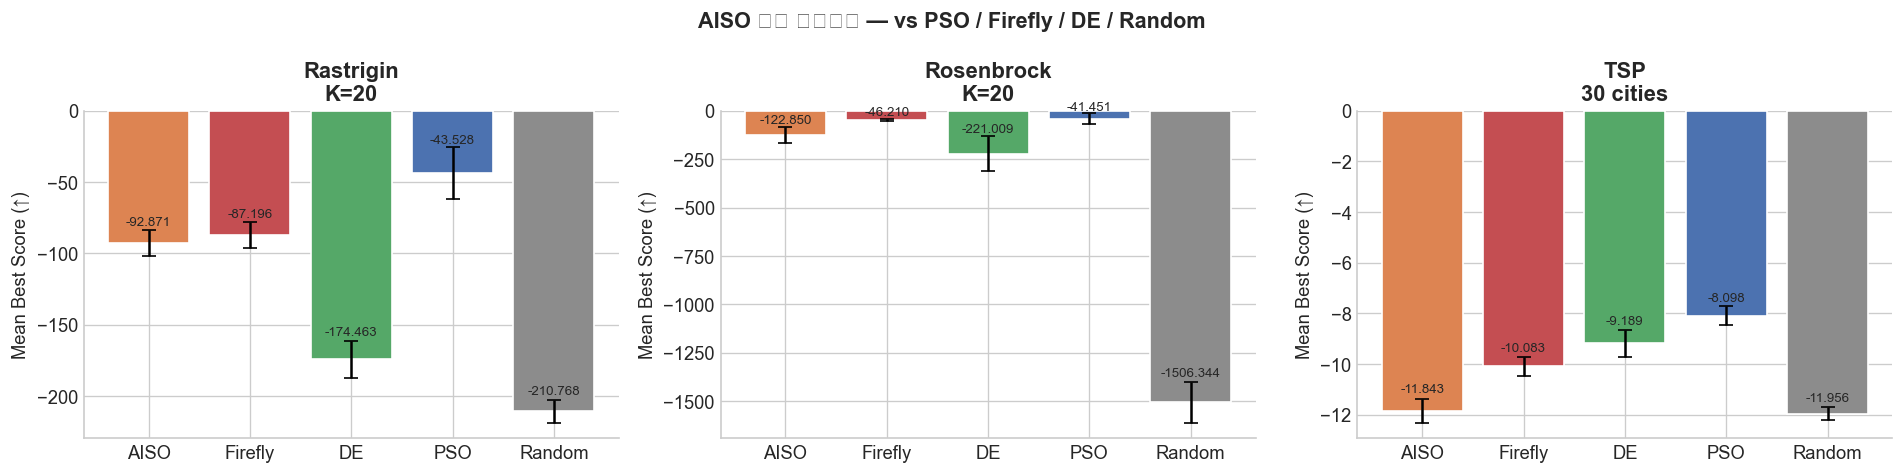

In [10]:
alg_order  = ['AISO', 'Firefly', 'DE', 'PSO', 'Random']
benchmarks = [('Rastrigin K=20', res_ras), ('Rosenbrock K=20', res_ros), (f'TSP {N_CITIES}cities', res_tsp)]

print('\n' + '='*75)
print(f'  {"":<22} ' + ''.join(f'{a:>11}' for a in alg_order))
print('  ' + '-'*70)
for label, res in benchmarks:
    best = max(np.mean(res[a]) for a in alg_order)
    row  = f'  {label:<22}'
    for a in alg_order:
        m = np.mean(res[a])
        row += f'  {m:>8.3f}{"★" if m==best else " "}'
    print(row)
print('='*75)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
blabels = [f'Rastrigin\nK={K_RAS}', f'Rosenbrock\nK={K_ROS}', f'TSP\n{N_CITIES} cities']
for ax, (label, res), bl in zip(axes, benchmarks, blabels):
    means  = [np.mean(res[a]) for a in alg_order]
    stds   = [np.std(res[a])  for a in alg_order]
    colors = [ALG_COLORS[a]   for a in alg_order]
    bars   = ax.bar(alg_order, means, color=colors, yerr=stds, capsize=4,
                    error_kw={'elinewidth':1.5}, edgecolor='white')
    ax.set_title(bl, fontweight='bold'); ax.set_ylabel('Mean Best Score (↑)')
    for bar,m,s in zip(bars,means,stds):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+abs(m)*0.01,
                f'{m:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('AISO 종합 벤치마크 — vs PSO / Firefly / DE / Random', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.savefig('benchmark_summary.png', bbox_inches='tight'); plt.show()